# Finite-difference entropy and inertial entropy flows

This notebook generates `fig:gradflow-second-order-momentum-entropy`.  The energy is the relative entropy with quadratic confinement
\[
    \mathcal F(\rho)=\int_{\mathbb R}\rho(x)\log\rho(x)\,dx+\frac12\int_{\mathbb R}x^2\rho(x)\,dx,
\]
whose Wasserstein gradient flow is the one-dimensional Ornstein--Uhlenbeck Fokker--Planck equation
\[
    \partial_t\rho_t=\partial_{xx}\rho_t+\partial_x(x\rho_t).
\]
Its stationary distribution is the centered Gaussian \(\mathcal N(0,1)\).  The inertial, or Newton, lift evolves a phase-space density \(\eta_t(x,s)\) according to
\[
    \partial_t\eta_t + \partial_x(s\eta_t)
    + \partial_s\!\left(\big(-\partial_x\log\rho_t(x)-x\big)\eta_t\right)=0,
    \qquad \rho_t(x)=\int \eta_t(x,s)\,ds.
\]
The figure compares these two PDE discretizations on the same three-Gaussian initial spatial density, with a narrow centered Gaussian initial velocity law for the Newton lift.

In [1]:
from pathlib import Path
import shutil
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import numpy as np
from scipy import sparse
from scipy.ndimage import gaussian_filter1d
from scipy.sparse.linalg import factorized


def find_repo_root(start):
    for path in (start, *start.parents):
        if (path / "latex" / "OT4ML.tex").exists() and (path / "notebooks-figures" / "figure_style.py").exists():
            return path
    raise RuntimeError("Could not locate the OT4ML repository root.")


ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "notebooks-figures"))
from figure_style import box_axes, interp_color, save_pdf, setup_matplotlib

setup_matplotlib()
out_dir = ROOT / "latex" / "figures" / "gradflow-second-order-momentum-entropy"
out_dir.mkdir(parents=True, exist_ok=True)
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(parents=True, exist_ok=True)

# Remove obsolete panels from the previous KDE-particle version.
for path in out_dir.glob("*.pdf"):
    path.unlink()


## Spatial and phase-space grids

The initial spatial density is a mixture of three one-dimensional Gaussians with different weights and widths.  The velocity marginal for the Newton equation is initialized as a small centered Gaussian, so the phase-space density initially lies near the zero-speed axis.  The spatial and speed windows are chosen tight enough to make the phase portrait readable while keeping negligible mass away from the boundary.

In [2]:
x_min, x_max, nx = -5.0, 5.0, 520
plot_x_min, plot_x_max = -3.65, 3.65
x = np.linspace(x_min, x_max, nx)
dx = x[1] - x[0]

s_min, s_max, ns = -4.0, 4.0, 320
plot_s_min, plot_s_max = -3.0, 3.0
s = np.linspace(s_min, s_max, ns)
ds = s[1] - s[0]


def gaussian_pdf(z, mean, sigma):
    return np.exp(-0.5 * ((z - mean) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)


def normalize_density(rho, grid):
    rho = np.maximum(rho, 0)
    return rho / np.trapezoid(rho, grid)


weights = np.array([0.22, 0.46, 0.32])
means = np.array([-1.55, -0.18, 1.12])
sigmas = np.array([0.22, 0.50, 0.33])
rho0 = sum(w * gaussian_pdf(x, m, sig) for w, m, sig in zip(weights, means, sigmas))
rho0 = normalize_density(rho0, x)
rho_inf = normalize_density(gaussian_pdf(x, 0.0, 1.0), x)

T = 0.6
times = np.array([0.0, 0.05, 0.12, 0.24, 0.40, 0.60])
colors = [interp_color(i / (len(times) - 1)) for i in range(len(times))]


## Overdamped Wasserstein gradient flow

The overdamped flow is discretized by a conservative finite-volume approximation of the OU/Fokker--Planck equation.  The time stepping is implicit Euler, so the grid step can remain small while the scheme stays stable and non-oscillatory.

In [3]:
def ou_operator(x_grid):
    # Finite-volume operator for rho_t = rho_xx + (x rho)_x with zero boundary flux.
    n = len(x_grid)
    h = x_grid[1] - x_grid[0]
    rows, cols, data = [], [], []
    for i in range(n - 1):
        x_half = 0.5 * (x_grid[i] + x_grid[i + 1])
        # Interface flux J = -rho_x - x rho, with rho averaged at the interface.
        a_left = 1.0 / h - 0.5 * x_half
        a_right = -1.0 / h - 0.5 * x_half
        rows += [i, i, i + 1, i + 1]
        cols += [i, i + 1, i, i + 1]
        data += [-a_left / h, -a_right / h, a_left / h, a_right / h]
    return sparse.csr_matrix((data, (rows, cols)), shape=(n, n))


dt_gf = 0.001
steps_gf = int(round(T / dt_gf))
save_steps_gf = {int(round(t / dt_gf)) for t in times}
L = ou_operator(x)
solve_gf = factorized((sparse.eye(nx, format="csc") - dt_gf * L).tocsc())

rho = rho0.copy()
gf_snaps = {0: rho.copy()}
for step in range(1, steps_gf + 1):
    rho = solve_gf(rho)
    rho = normalize_density(rho, x)
    if step in save_steps_gf:
        gf_snaps[step] = rho.copy()

gf_list = [gf_snaps[int(round(t / dt_gf))] for t in times]


## Newton lift on phase space

The Newton lift is a two-dimensional conservative upwind scheme in \((x,s)\).  The acceleration field is computed from the spatial marginal \(\rho_t\) by a finite-difference approximation of \(-\partial_x\log\rho_t-x\).  A small density floor and mild one-grid-cell smoothing prevent division by tiny tail values; this is a numerical regularization of the grid score, not a KDE particle closure.

In [4]:
velocity_sigma = 0.16
eta = rho0[:, None] * gaussian_pdf(s[None, :], 0.0, velocity_sigma)
eta = np.maximum(eta, 0)
eta /= eta.sum() * dx * ds

dt = 0.0005
steps = int(round(T / dt))
save_steps = {int(round(t / dt)) for t in times}
force_clip = 9.0
smooth_sigma_grid = 1.25
rho_floor = 1.5e-5

newton_spatial = {0: eta.sum(axis=1) * ds}
newton_phase = {0: eta.copy()}

for step in range(1, steps + 1):
    rho_x = eta.sum(axis=1) * ds
    rho_smooth = gaussian_filter1d(rho_x, smooth_sigma_grid, mode="nearest")
    rho_smooth = np.maximum(rho_smooth, rho_floor)
    score = np.gradient(np.log(rho_smooth), dx, edge_order=2)
    acceleration = np.clip(-score - x, -force_clip, force_clip)

    # Upwind flux in the spatial direction, velocity s.
    flux_x = np.zeros((nx + 1, ns))
    pos_s = s > 0
    neg_s = ~pos_s
    flux_x[1:nx, pos_s] = s[pos_s] * eta[:-1, pos_s]
    flux_x[1:nx, neg_s] = s[neg_s] * eta[1:, neg_s]

    # Upwind flux in the speed direction, acceleration a(x).
    flux_s = np.zeros((nx, ns + 1))
    pos_a = acceleration > 0
    neg_a = ~pos_a
    flux_s[pos_a, 1:ns] = acceleration[pos_a, None] * eta[pos_a, :-1]
    flux_s[neg_a, 1:ns] = acceleration[neg_a, None] * eta[neg_a, 1:]

    eta = eta - dt * ((flux_x[1:] - flux_x[:-1]) / dx + (flux_s[:, 1:] - flux_s[:, :-1]) / ds)
    eta = np.maximum(eta, 0)
    eta /= eta.sum() * dx * ds

    if step in save_steps:
        newton_spatial[step] = eta.sum(axis=1) * ds
        newton_phase[step] = eta.copy()

newton_spatial_list = [newton_spatial[int(round(t / dt))] for t in times]
newton_phase_list = [newton_phase[int(round(t / dt))] for t in times]


## Render individual PDF panels

Each time snapshot is saved as a separate PDF panel.  The LaTeX source arranges these panels into three rows: the GF spatial density, the Newton spatial density, and the Newton phase-space density.  The dashed gray curve in the spatial panels is the stationary centered Gaussian.

In [5]:
ymax = 1.08 * max(
    max(r.max() for r in gf_list),
    max(r.max() for r in newton_spatial_list),
    rho_inf.max(),
)
phase_vmax = np.percentile(np.concatenate([p.ravel() for p in newton_phase_list]), 99.35)


def plot_spatial_density(rho, color, path):
    fig, ax = plt.subplots(figsize=(1.55, 1.02))
    ax.fill_between(x, 0, rho, color=color, alpha=0.22, lw=0)
    ax.plot(x, rho, color=color, lw=1.35)
    ax.plot(x, rho_inf, color="#555555", lw=0.65, ls=(0, (3, 2)), alpha=0.78)
    ax.set_xlim(plot_x_min, plot_x_max)
    ax.set_ylim(0, ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)
    save_pdf(fig, path, pad_inches=0.015)
    plt.close(fig)


def plot_phase_density(eta_snapshot, path):
    fig, ax = plt.subplots(figsize=(1.55, 1.18))
    ax.imshow(
        np.clip(eta_snapshot.T, 0, phase_vmax),
        origin="lower",
        extent=[x_min, x_max, s_min, s_max],
        aspect="auto",
        cmap="Greys",
        norm=PowerNorm(gamma=0.72, vmin=0, vmax=phase_vmax),
        interpolation="bilinear",
    )
    ax.axhline(0, color="#777777", lw=0.35, alpha=0.65)
    ax.set_xlim(plot_x_min, plot_x_max)
    ax.set_ylim(plot_s_min, plot_s_max)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)
    save_pdf(fig, path, pad_inches=0.015)
    plt.close(fig)


for i, (time, color) in enumerate(zip(times, colors)):
    tag = f"t{i:02d}"
    plot_spatial_density(gf_list[i], color, out_dir / f"gf-spatial-{tag}.pdf")
    plot_spatial_density(newton_spatial_list[i], color, out_dir / f"newton-spatial-{tag}.pdf")
    plot_phase_density(newton_phase_list[i], out_dir / f"newton-phase-{tag}.pdf")


## Notebook preview and mirror for PDE4ML

The composite preview is used as the figure-gallery thumbnail.  The generated PDF panels are also mirrored into `PDE4ML/figures/` because the PDE4ML survey reuses this material.

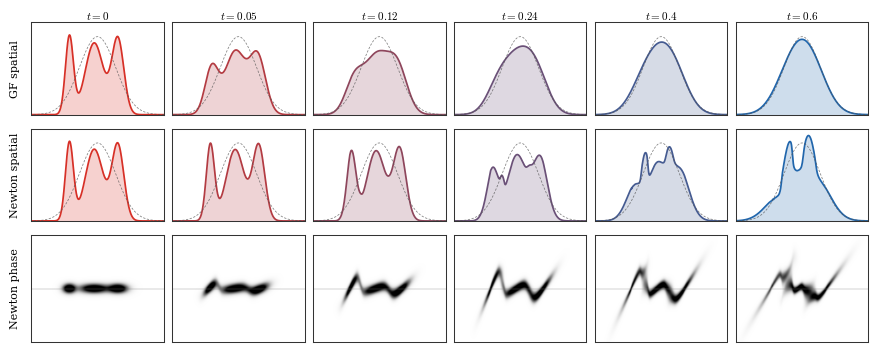

Wrote 18 PDF panels to latex/figures/gradflow-second-order-momentum-entropy
Updated thumbnail notebooks-figures/thumbnails/gradflow-second-order-momentum-entropy.png


In [6]:
fig, axes = plt.subplots(
    3,
    len(times),
    figsize=(10.8, 4.15),
    gridspec_kw={"height_ratios": [1.0, 1.0, 1.16], "wspace": 0.065, "hspace": 0.145},
)
for i, (time, color) in enumerate(zip(times, colors)):
    ax = axes[0, i]
    ax.fill_between(x, 0, gf_list[i], color=color, alpha=0.22, lw=0)
    ax.plot(x, gf_list[i], color=color, lw=1.25)
    ax.plot(x, rho_inf, color="#555555", lw=0.55, ls=(0, (3, 2)), alpha=0.75)
    ax.set_xlim(plot_x_min, plot_x_max)
    ax.set_ylim(0, ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)

    ax = axes[1, i]
    ax.fill_between(x, 0, newton_spatial_list[i], color=color, alpha=0.22, lw=0)
    ax.plot(x, newton_spatial_list[i], color=color, lw=1.25)
    ax.plot(x, rho_inf, color="#555555", lw=0.55, ls=(0, (3, 2)), alpha=0.75)
    ax.set_xlim(plot_x_min, plot_x_max)
    ax.set_ylim(0, ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)

    ax = axes[2, i]
    ax.imshow(
        np.clip(newton_phase_list[i].T, 0, phase_vmax),
        origin="lower",
        extent=[x_min, x_max, s_min, s_max],
        aspect="auto",
        cmap="Greys",
        norm=PowerNorm(gamma=0.72, vmin=0, vmax=phase_vmax),
        interpolation="bilinear",
    )
    ax.axhline(0, color="#777777", lw=0.35, alpha=0.65)
    ax.set_xlim(plot_x_min, plot_x_max)
    ax.set_ylim(plot_s_min, plot_s_max)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)

for row, label in enumerate(["GF spatial", "Newton spatial", "Newton phase"]):
    axes[row, 0].set_ylabel(label, rotation=90, labelpad=8, fontsize=8)
for i, time in enumerate(times):
    axes[0, i].set_title(f"$t={time:g}$", fontsize=8, pad=2)

thumb_path = thumb_dir / "gradflow-second-order-momentum-entropy.png"
fig.savefig(thumb_path, dpi=180, bbox_inches="tight", pad_inches=0.035)
plt.show()

pde_dir = ROOT / "PDE4ML" / "figures" / "gradflow-second-order-momentum-entropy"
pde_dir.mkdir(parents=True, exist_ok=True)
for path in pde_dir.glob("*.pdf"):
    path.unlink()
for path in out_dir.glob("*.pdf"):
    shutil.copy2(path, pde_dir / path.name)

print(f"Wrote {len(list(out_dir.glob('*.pdf')))} PDF panels to {out_dir.relative_to(ROOT)}")
print(f"Updated thumbnail {thumb_path.relative_to(ROOT)}")
